# Exploratory Data Analysis and Data Visualisation

This section explores the Instacart dataset to understand its structure, customer ordering behaviour, product characteristics, reorder patterns, and purchasing preferences across different departments and aisles.

In [ ]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [ ]:
order_products_train = pd.read_csv('order_products__train.csv')
order_products_prior = pd.read_csv('order_products__prior.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')

### Loading the Dataset

The dataset consists of information on orders, products, aisles, departments, and the products included in each order. The train and prior order-product datasets are combined where required to obtain a complete view of product purchasing behaviour.

In [ ]:
print("The order_products_train size is : ", order_products_train.shape)
print("The order_products_prior size is : ", order_products_prior.shape)

The order_products_train size is :  (1384617, 4)
The order_products_prior size is :  (32434489, 4)


In [ ]:
order_products_train.head(5)

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [ ]:
order_products_prior.head(5)

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


### Combining Order-Product Data

The training and prior order-product datasets are combined to create a single dataset containing product-level information for all available orders. This combined dataset is used for most of the subsequent exploratory analysis.

In [ ]:
order_products_all = pd.concat([order_products_train, order_products_prior], axis=0)
order_products_all.head(5)
print("The order_products_all size is : ", order_products_all.shape)

The order_products_all size is :  (33819106, 4)


### Checking for Missing Values

Before proceeding with the analysis, we check the combined order-product data for missing values. This helps ensure that missing observations do not affect the subsequent analysis.

In [ ]:
total = order_products_all.isnull().sum().sort_values(ascending=False)
percent = (order_products_all.isnull().sum() / order_products_all.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head()

,Total,Percent
order_id,0,0.000
product_id,0,0.000
add_to_cart_order,0,0.000
reordered,0,0.000


The order-product data contains no missing values in the variables examined.

### Dataset Coverage

We next examine the number of unique orders and products represented in the combined dataset. This provides an overview of the scale and coverage of the purchasing data.

In [ ]:
orders_Unique = len(set(order_products_all.order_id))
products_Unique = len(set(order_products_all.product_id))
print("There are %s orders for %s products" %(orders_Unique, products_Unique))

There are 3346083 orders for 49685 products


### Distribution of Products per Order

The number of products added to each order is examined to understand the typical basket size of customers. The distribution helps identify whether customers generally place smaller or larger orders.

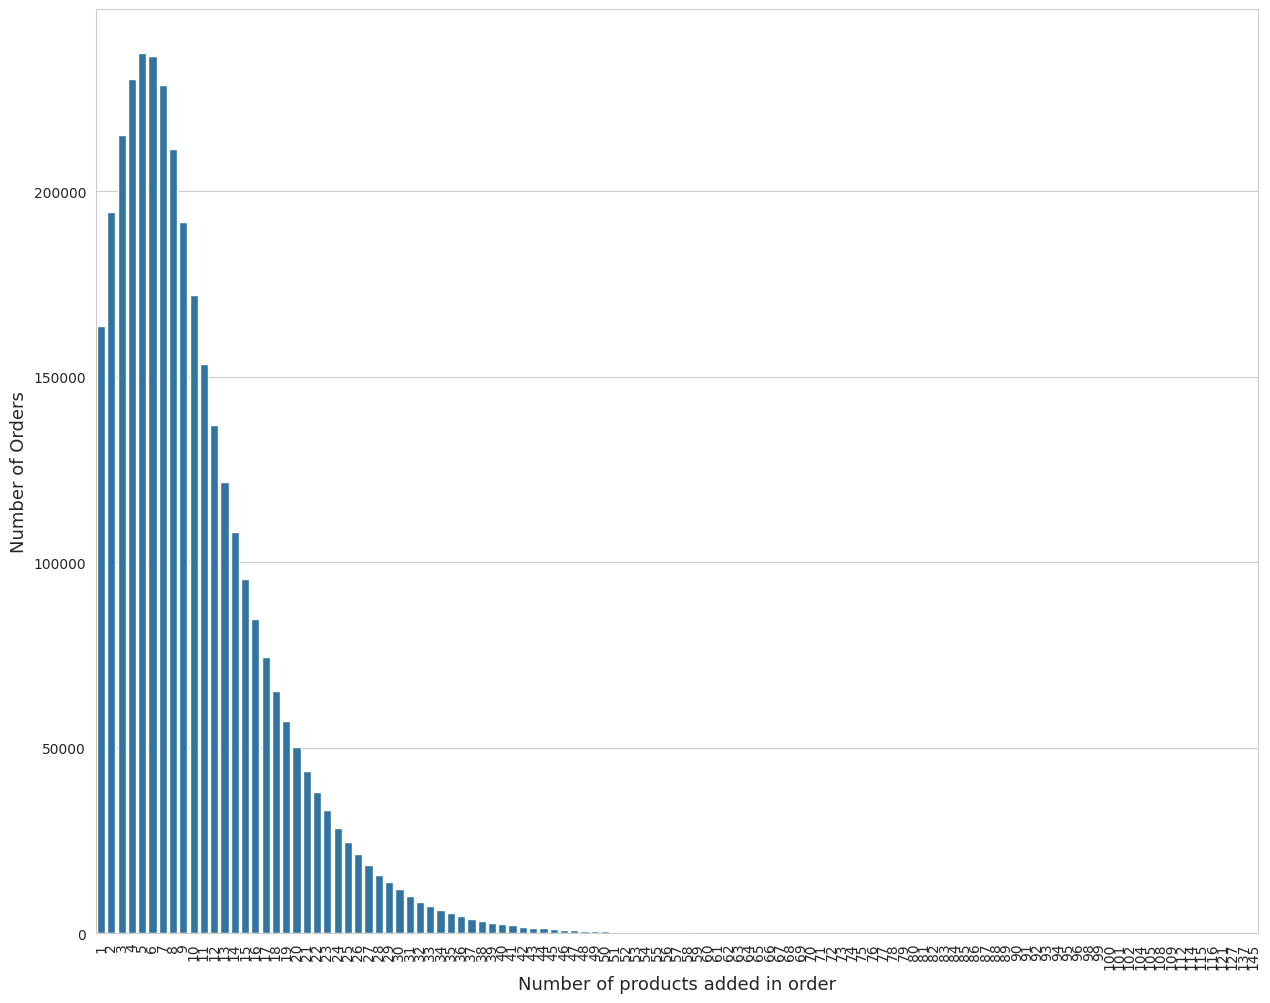

In [ ]:
grouped = order_products_all.groupby("order_id")["add_to_cart_order"].aggregate("max").reset_index()
grouped = grouped.add_to_cart_order.value_counts()

sns.set_style('whitegrid')
f, ax = plt.subplots(figsize=(15, 12))
plt.xticks(rotation='vertical')
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of Orders', fontsize=13)
plt.xlabel('Number of products added in order', fontsize=13)
plt.show()

### Most Frequently Reordered Products

We identify the products with the highest number of reorder occurrences. This helps highlight products that customers repeatedly purchase and therefore appear to be important in regular purchasing behaviour.

In [ ]:
grouped = order_products_all.groupby("product_id")["reordered"].count().reset_index(name="Total_reorders")
grouped = pd.merge(grouped, products[['product_id', 'product_name']], how='left', on=['product_id'])
grouped = grouped.sort_values(by='Total_reorders', ascending=False)[:10]
grouped

,product_id,Total_reorders,product_name
24849,24852,491291,Banana
13173,13176,394930,Bag of Organic Bananas
21134,21137,275577,Organic Strawberries
21900,21903,251705,Organic Baby Spinach
47205,47209,220877,Organic Hass Avocado
47762,47766,184224,Organic Avocado
47622,47626,160792,Large Lemon
16794,16797,149445,Strawberries
26206,26209,146660,Limes
27842,27845,142813,Organic Whole Milk


The following visualization shows the products with the highest number of reorders.

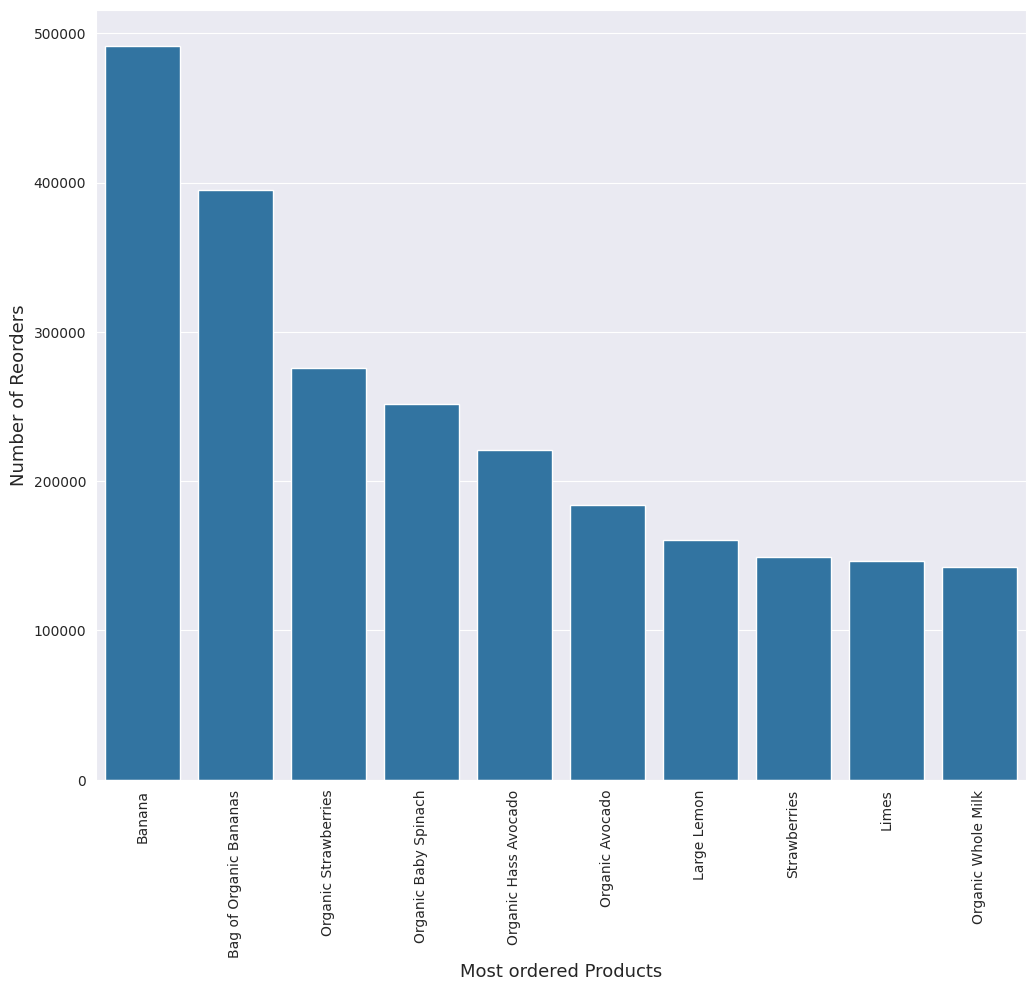

In [ ]:
grouped  = grouped.groupby(['product_name']).sum()['Total_reorders'].sort_values(ascending=False)

sns.set_style('darkgrid')
f, ax = plt.subplots(figsize=(12, 10))
plt.xticks(rotation='vertical')
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of Reorders', fontsize=13)
plt.xlabel('Most ordered Products', fontsize=13)
plt.show()

In [ ]:
grouped = order_products_all.groupby("reordered")["product_id"] \
           .agg('count') \
           .reset_index() \
           .rename(columns={"product_id": "Total_products"})

grouped['Ratios'] = grouped["Total_products"] / grouped["Total_products"].sum()
grouped

,reordered,Total_products,Ratios
0,0,13863746,0.410
1,1,19955360,0.590


### Reordering Behaviour

The dataset distinguishes between products that were reordered and products that were purchased for the first time. We examine their overall proportions to understand the extent of repeat purchasing in the dataset.

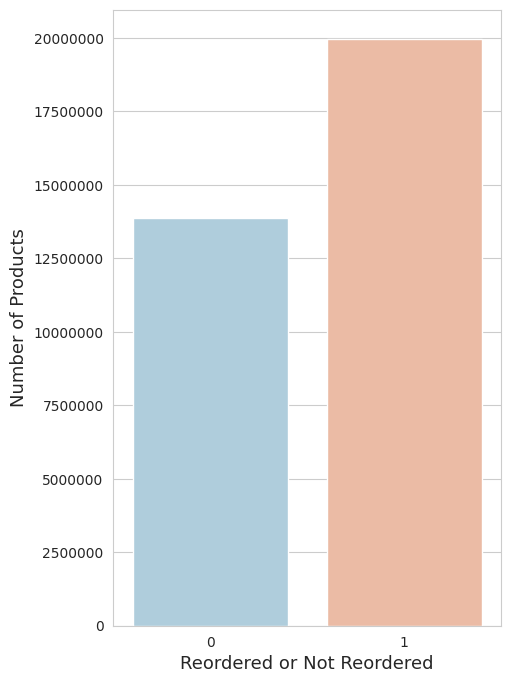

In [ ]:
sns.set_style('whitegrid')
f, ax = plt.subplots(figsize=(5, 8))
sns.barplot(x=grouped['reordered'], y=grouped['Total_products'], palette='RdBu_r')
plt.ylabel('Number of Products', fontsize=13)
plt.xlabel('Reordered or Not Reordered', fontsize=13)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Products with the Highest Reorder Probability

Instead of considering only the total number of reorders, we calculate the probability that a product is reordered whenever it appears in an order. To avoid products with very few observations dominating the results, only products appearing more than 75 times are considered.

In [ ]:
grouped = order_products_all.groupby("product_id").agg(
    reorder_sum=('reordered', 'sum'),
    reorder_total=('reordered', 'count')
).reset_index()

grouped['reorder_probability'] = grouped['reorder_sum'] / grouped['reorder_total']
grouped = pd.merge(grouped, products[['product_id', 'product_name']], how='left', on=['product_id'])
grouped = grouped[grouped.reorder_total > 75].sort_values(['reorder_probability'], ascending=False)[:10]
grouped

,product_id,reorder_sum,reorder_total,reorder_probability,product_name
2074,2075,84,90,0.933,Serenity Ultimate Extrema Overnight Pads
27737,27740,94,102,0.922,Chocolate Love Bar
35601,35604,93,104,0.894,Maca Buttercups
38248,38251,99,111,0.892,Benchbreak Chardonnay
36798,36801,88,99,0.889,Organic Blueberry B Mega
10233,10236,114,131,0.870,Fragrance Free Clay with Natural Odor Eliminat...
20595,20598,99,114,0.868,Thousand Island Salad Snax
5455,5457,78,90,0.867,Classic Carbonated Natural Mineral Water
35493,35496,394,457,0.862,Real2 Alkalized Water 500 ml
9289,9292,2580,2995,0.861,Half And Half Ultra Pasteurized


The following plot presents the products with the highest estimated reorder probabilities.

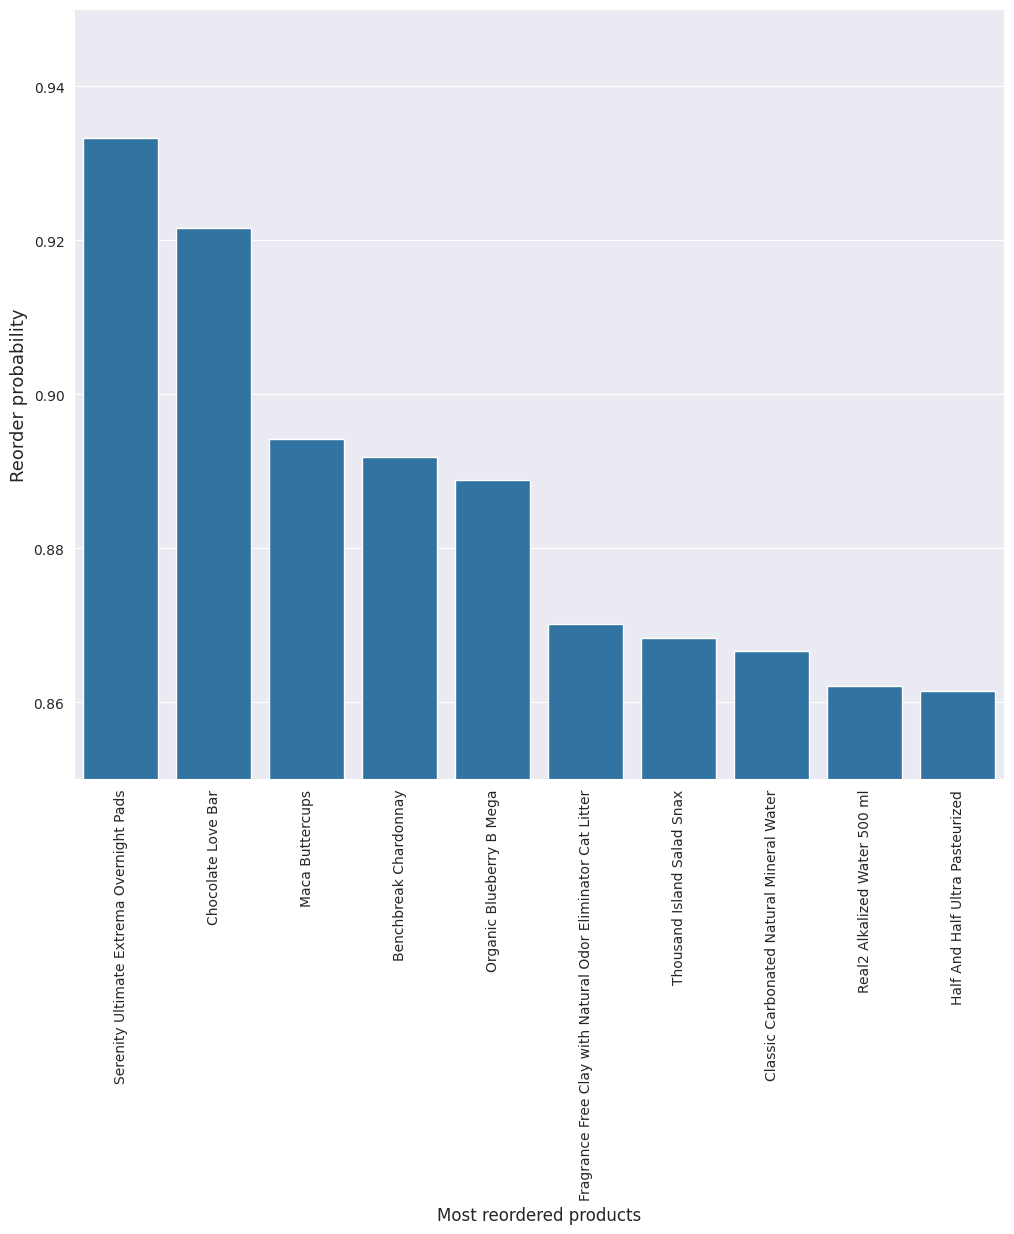

In [ ]:
sns.set_style('darkgrid')
f, ax = plt.subplots(figsize=(12, 10))
plt.xticks(rotation='vertical')
sns.barplot(x=grouped['product_name'], y=grouped['reorder_probability'])
plt.ylim([0.85,0.95])
plt.ylabel('Reorder probability', fontsize=13)
plt.xlabel('Most reordered products', fontsize=12)
plt.show()

## Customer and Order-Level Analysis

We now shift from product-level information to the orders dataset to examine when customers place orders, how frequently they reorder, and how orders are distributed across the available evaluation sets.

In [ ]:
print("The orders data size is : ", orders.shape)
print("Columns in orders data are: ", orders.columns.values)

The orders data size is :  (3421083, 7)
Columns in orders data are:  ['order_id' 'user_id' 'eval_set' 'order_number' 'order_dow'
 'order_hour_of_day' 'days_since_prior_order']


### Missing Values in the Orders Dataset

We examine the percentage of missing observations in the order-level variables. Understanding the missingness is important before analysing customer ordering patterns.

In [ ]:
orders.head(5)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.000
2,473747,1,prior,3,3,12,21.000
3,2254736,1,prior,4,4,7,29.000
4,431534,1,prior,5,4,15,28.000


In [ ]:
orders_na = (orders.isnull().sum() / len(orders)) * 100
orders_na = orders_na.drop(orders_na[orders_na == 0].index).sort_values(ascending=False)
orders_na

,0
days_since_prior_order,6.028


### Distribution of Orders by Time of Day

We examine the hour at which orders are placed to identify the periods of the day during which customer ordering activity is highest.

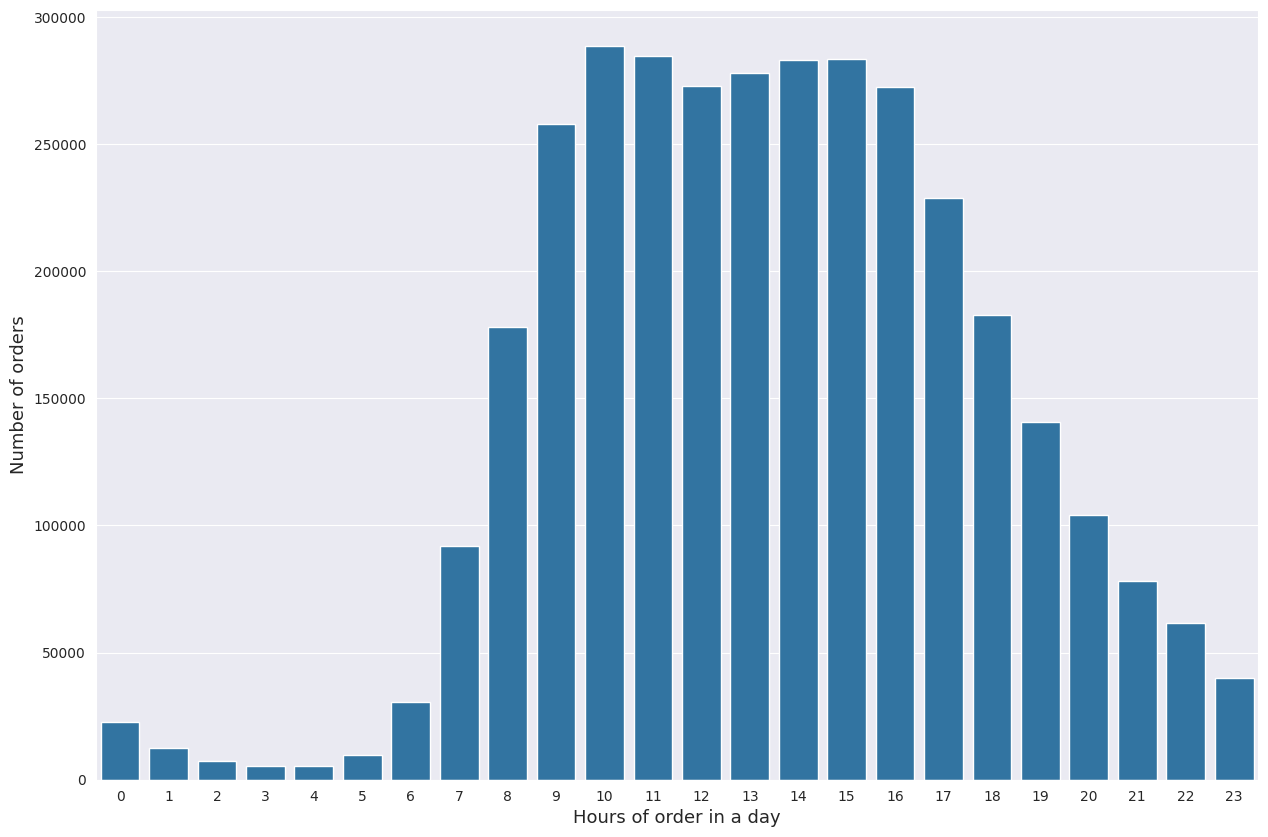

In [ ]:
grouped = orders.groupby("order_id")["order_hour_of_day"].aggregate("sum").reset_index()
grouped = grouped.order_hour_of_day.value_counts()

sns.set_style('darkgrid')
f, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of orders', fontsize=13)
plt.xlabel('Hours of order in a day', fontsize=13)
plt.show()

### Time Between Consecutive Orders

The number of days since a customer's previous order is examined to understand the typical interval between purchases and the frequency of repeat ordering.

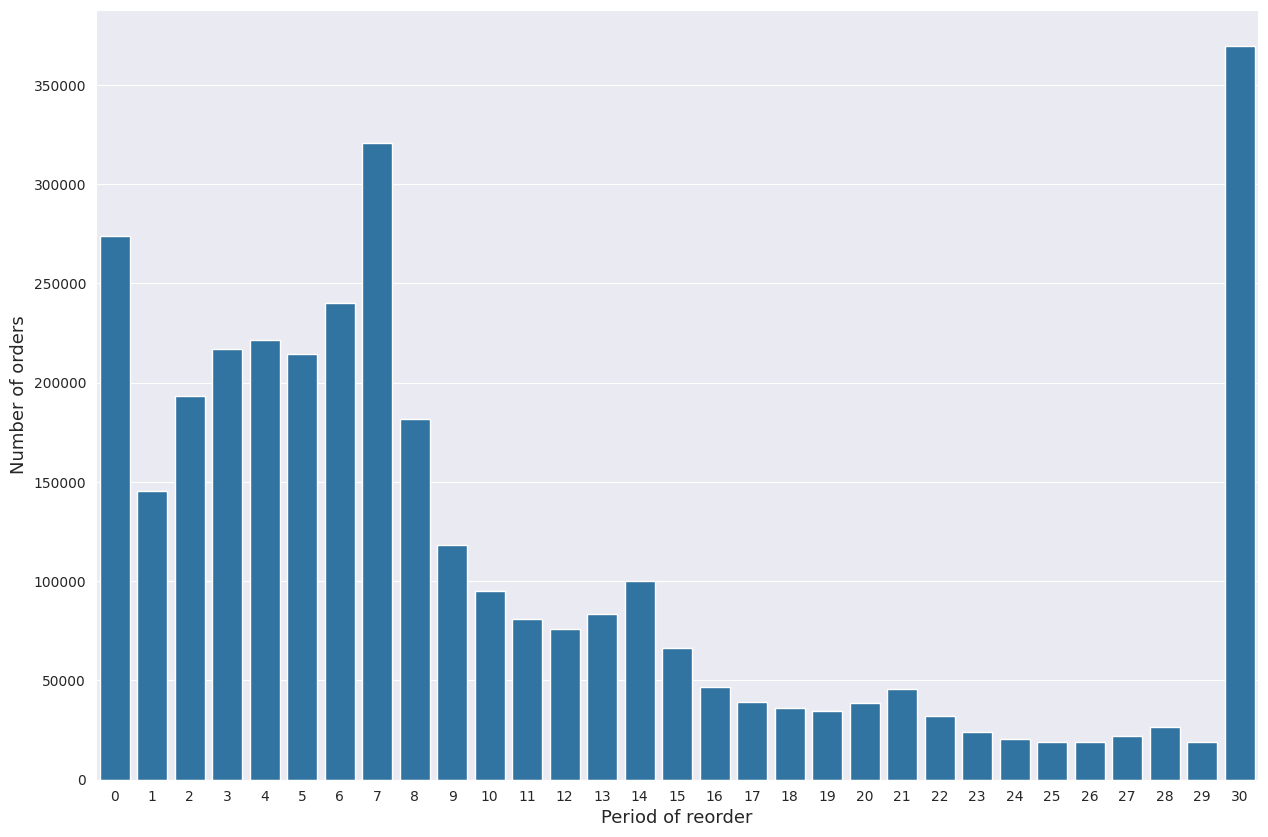

In [ ]:
grouped = orders.groupby("order_id")["days_since_prior_order"].aggregate("sum").reset_index()
grouped = grouped.days_since_prior_order.value_counts()

from matplotlib.ticker import FormatStrFormatter
f, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x=grouped.index, y=grouped.values)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.ylabel('Number of orders', fontsize=13)
plt.xlabel('Period of reorder', fontsize=13)
plt.show()

### Distribution of Orders Across the Week

We examine the day of the week on which orders are placed to identify weekly patterns in customer purchasing activity.

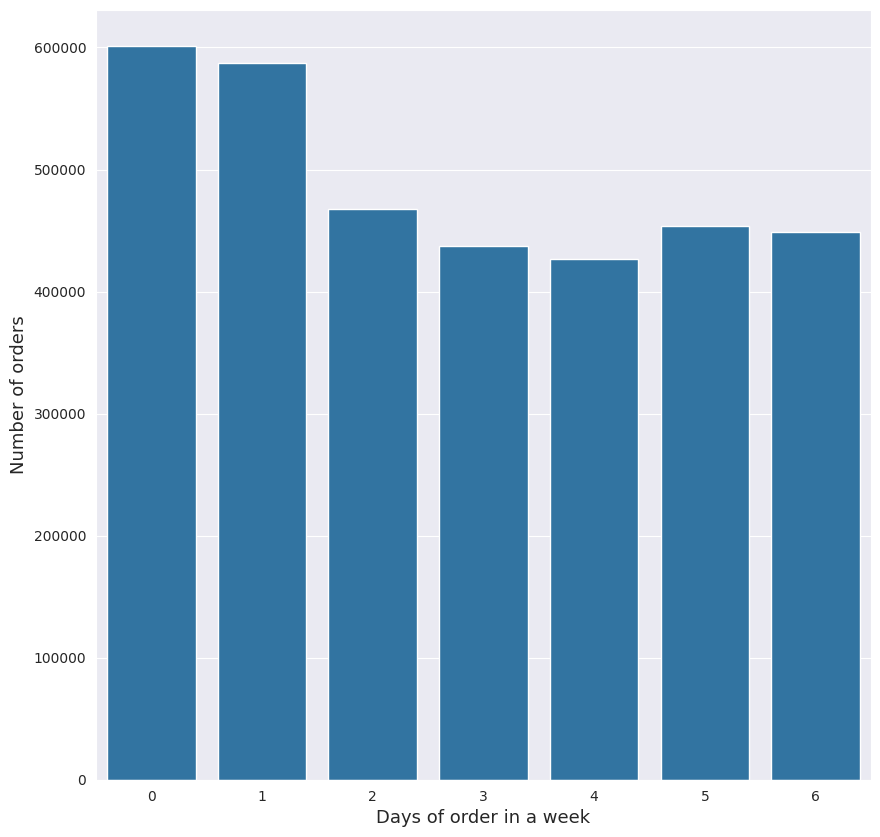

In [ ]:
grouped = orders.groupby("order_id")["order_dow"].aggregate("sum").reset_index()
grouped = grouped.order_dow.value_counts()

f, ax = plt.subplots(figsize=(10, 10))
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of orders', fontsize=13)
plt.xlabel('Days of order in a week', fontsize=13)
plt.show()

### Distribution Across Evaluation Sets

The orders are divided into different evaluation sets used in the original dataset. We examine their relative sizes to understand how the available orders are distributed across these groups.

In [ ]:
grouped = orders.groupby("eval_set").agg(Total_orders=('order_id', 'count')).reset_index()
grouped['Ratio'] = grouped["Total_orders"] / grouped["Total_orders"].sum()
grouped

,eval_set,Total_orders,Ratio
0,prior,3214874,0.940
1,test,75000,0.022
2,train,131209,0.038


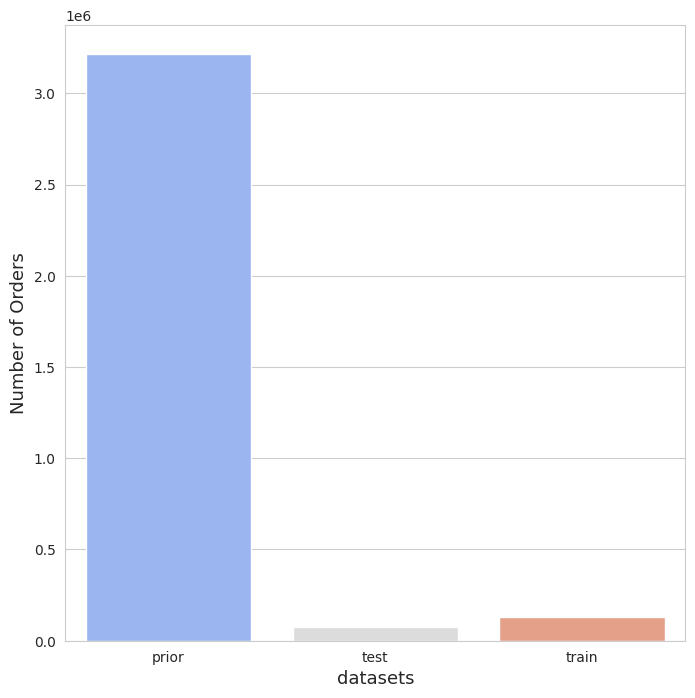

In [ ]:
sns.set_style('whitegrid')
f, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=grouped['eval_set'], y=grouped['Total_orders'], palette='coolwarm')
plt.ylabel('Number of Orders', fontsize=13)
plt.xlabel('datasets', fontsize=13)
plt.show()

### Customer Base

We calculate the number of unique customers represented in the dataset to understand the size of the customer base being analysed.

In [ ]:
print("Number of unique customers in the whole dataset: ",len(set(orders.user_id)))

Number of unique customers in the whole dataset:  206209


The number of unique customers in each evaluation set is compared to examine how customers are distributed across the different groups.

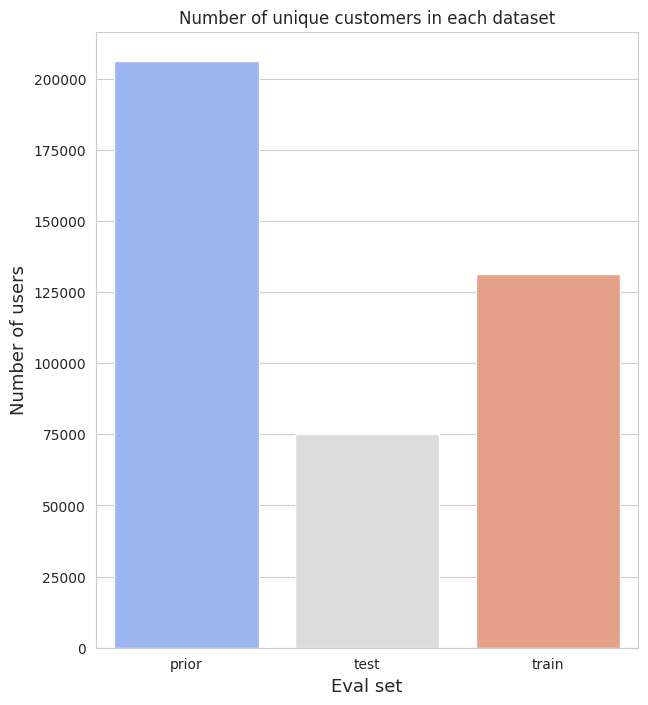

In [ ]:
grouped = orders.groupby("eval_set")["user_id"].nunique()

plt.figure(figsize=(7,8))
sns.barplot(x=grouped.index, y=grouped.values, palette='coolwarm')
plt.ylabel('Number of users', fontsize=13)
plt.xlabel('Eval set', fontsize=13)
plt.title("Number of unique customers in each dataset")
plt.show()

### Number of Orders per Customer

We examine how many orders are placed by each customer. This provides an indication of customer purchasing frequency and helps identify whether the dataset is dominated by occasional or repeat customers.

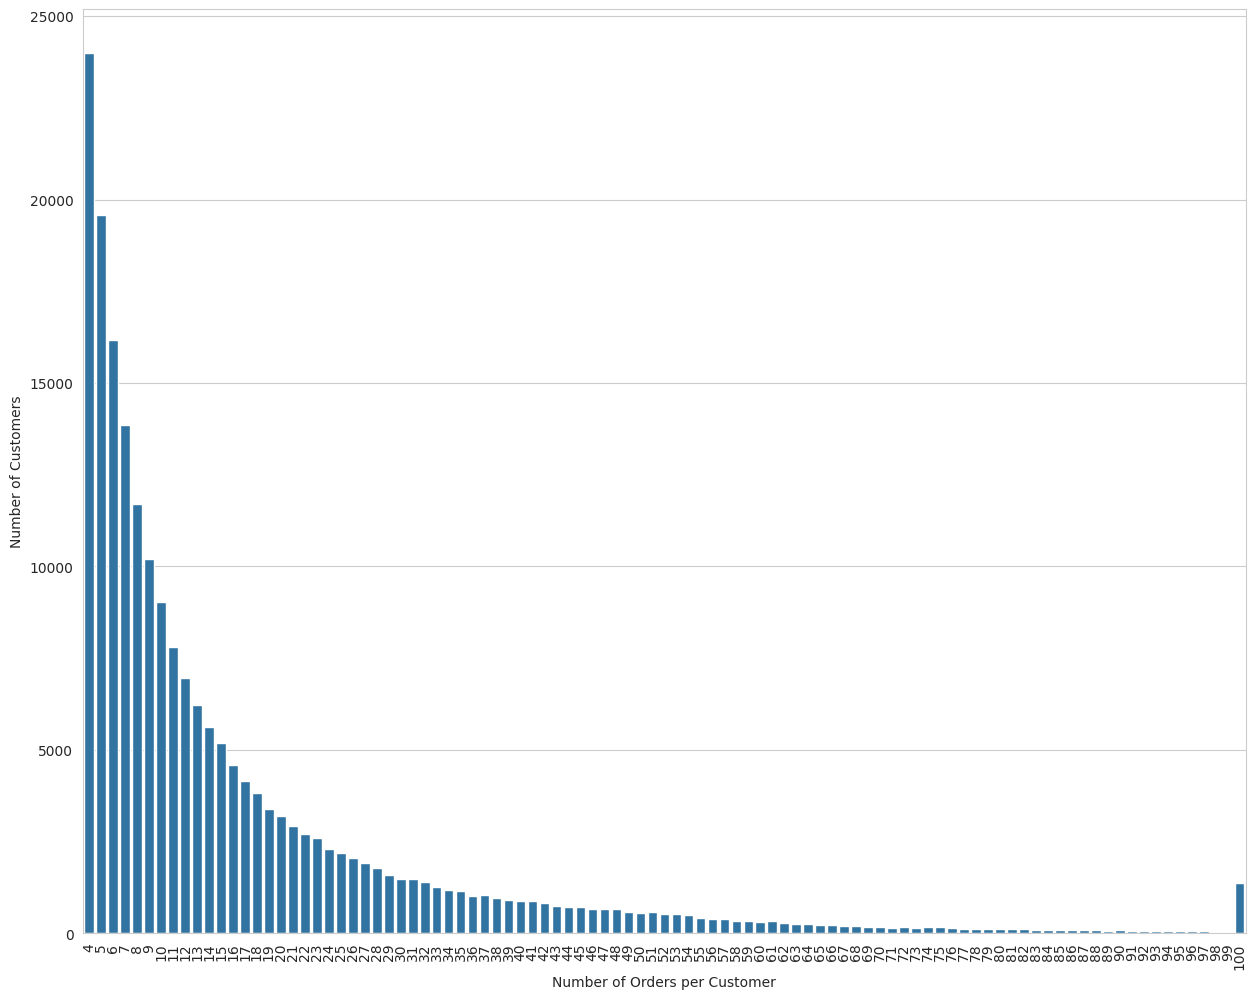

In [ ]:
grouped = orders.groupby('user_id')['order_id'].nunique().reset_index()
grouped = grouped.groupby('order_id').size()

sns.set_style("whitegrid")
f, ax = plt.subplots(figsize=(15, 12))
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of Customers')
plt.xlabel('Number of Orders per Customer')
plt.xticks(rotation='vertical')
plt.show()

## Product and Department Analysis

The product catalogue is organised into departments and aisles. We combine these datasets to examine the structure of the product assortment and understand how products are distributed across different categories.

In [ ]:
products.head(5)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
departments.head(5)

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [ ]:
aisles.head(5)

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [ ]:
items = pd.merge(left =pd.merge(left=products, right=departments, how='left'), right=aisles, how='left')
items.head()

,product_id,product_name,aisle_id,department_id,department,aisle
0,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes
1,2,All-Seasons Salt,104,13,pantry,spices seasonings
2,3,Robust Golden Unsweetened Oolong Tea,94,7,beverages,tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen,frozen meals
4,5,Green Chile Anytime Sauce,5,13,pantry,marinades meat preparation


### Number of Products by Department

We calculate the number of products available in each department to understand the composition of the product catalogue and identify departments with the largest product variety.

In [ ]:
grouped = items.groupby("department").agg(Total_products=('product_id', 'count')).reset_index()
grouped['Ratio'] = grouped["Total_products"] / grouped["Total_products"].sum()
grouped = grouped.sort_values(by='Total_products', ascending=False)
grouped

,department,Total_products,Ratio
17,personal care,6563,0.132
20,snacks,6264,0.126
16,pantry,5371,0.108
3,beverages,4365,0.088
10,frozen,4007,0.081
7,dairy eggs,3449,0.069
11,household,3085,0.062
6,canned goods,2092,0.042
9,dry goods pasta,1858,0.037
19,produce,1684,0.034


The following visualization compares the number of products across departments.

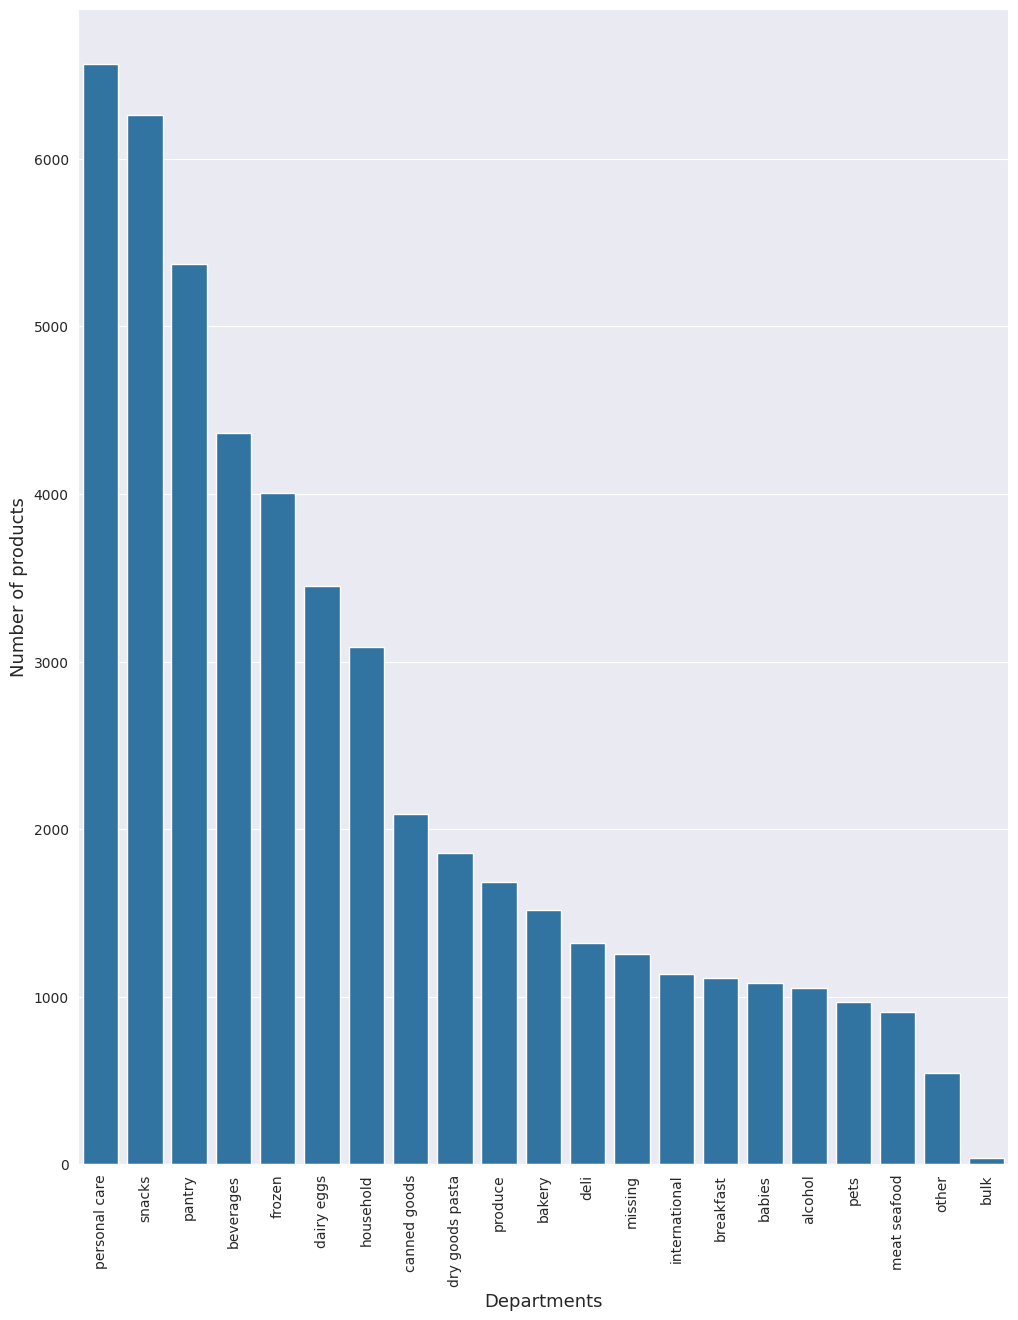

In [ ]:
sns.set_style("darkgrid")
f, ax = plt.subplots(figsize=(12, 15))
plt.xticks(rotation='vertical')
sns.barplot(x=grouped['department'], y=grouped['Total_products'])
plt.ylabel('Number of products', fontsize=13)
plt.xlabel('Departments', fontsize=13)
plt.show()

### Product Distribution Across Aisles

We further examine the distribution of products across aisles within each department. This provides a more detailed view of the product catalogue than the department-level analysis alone.

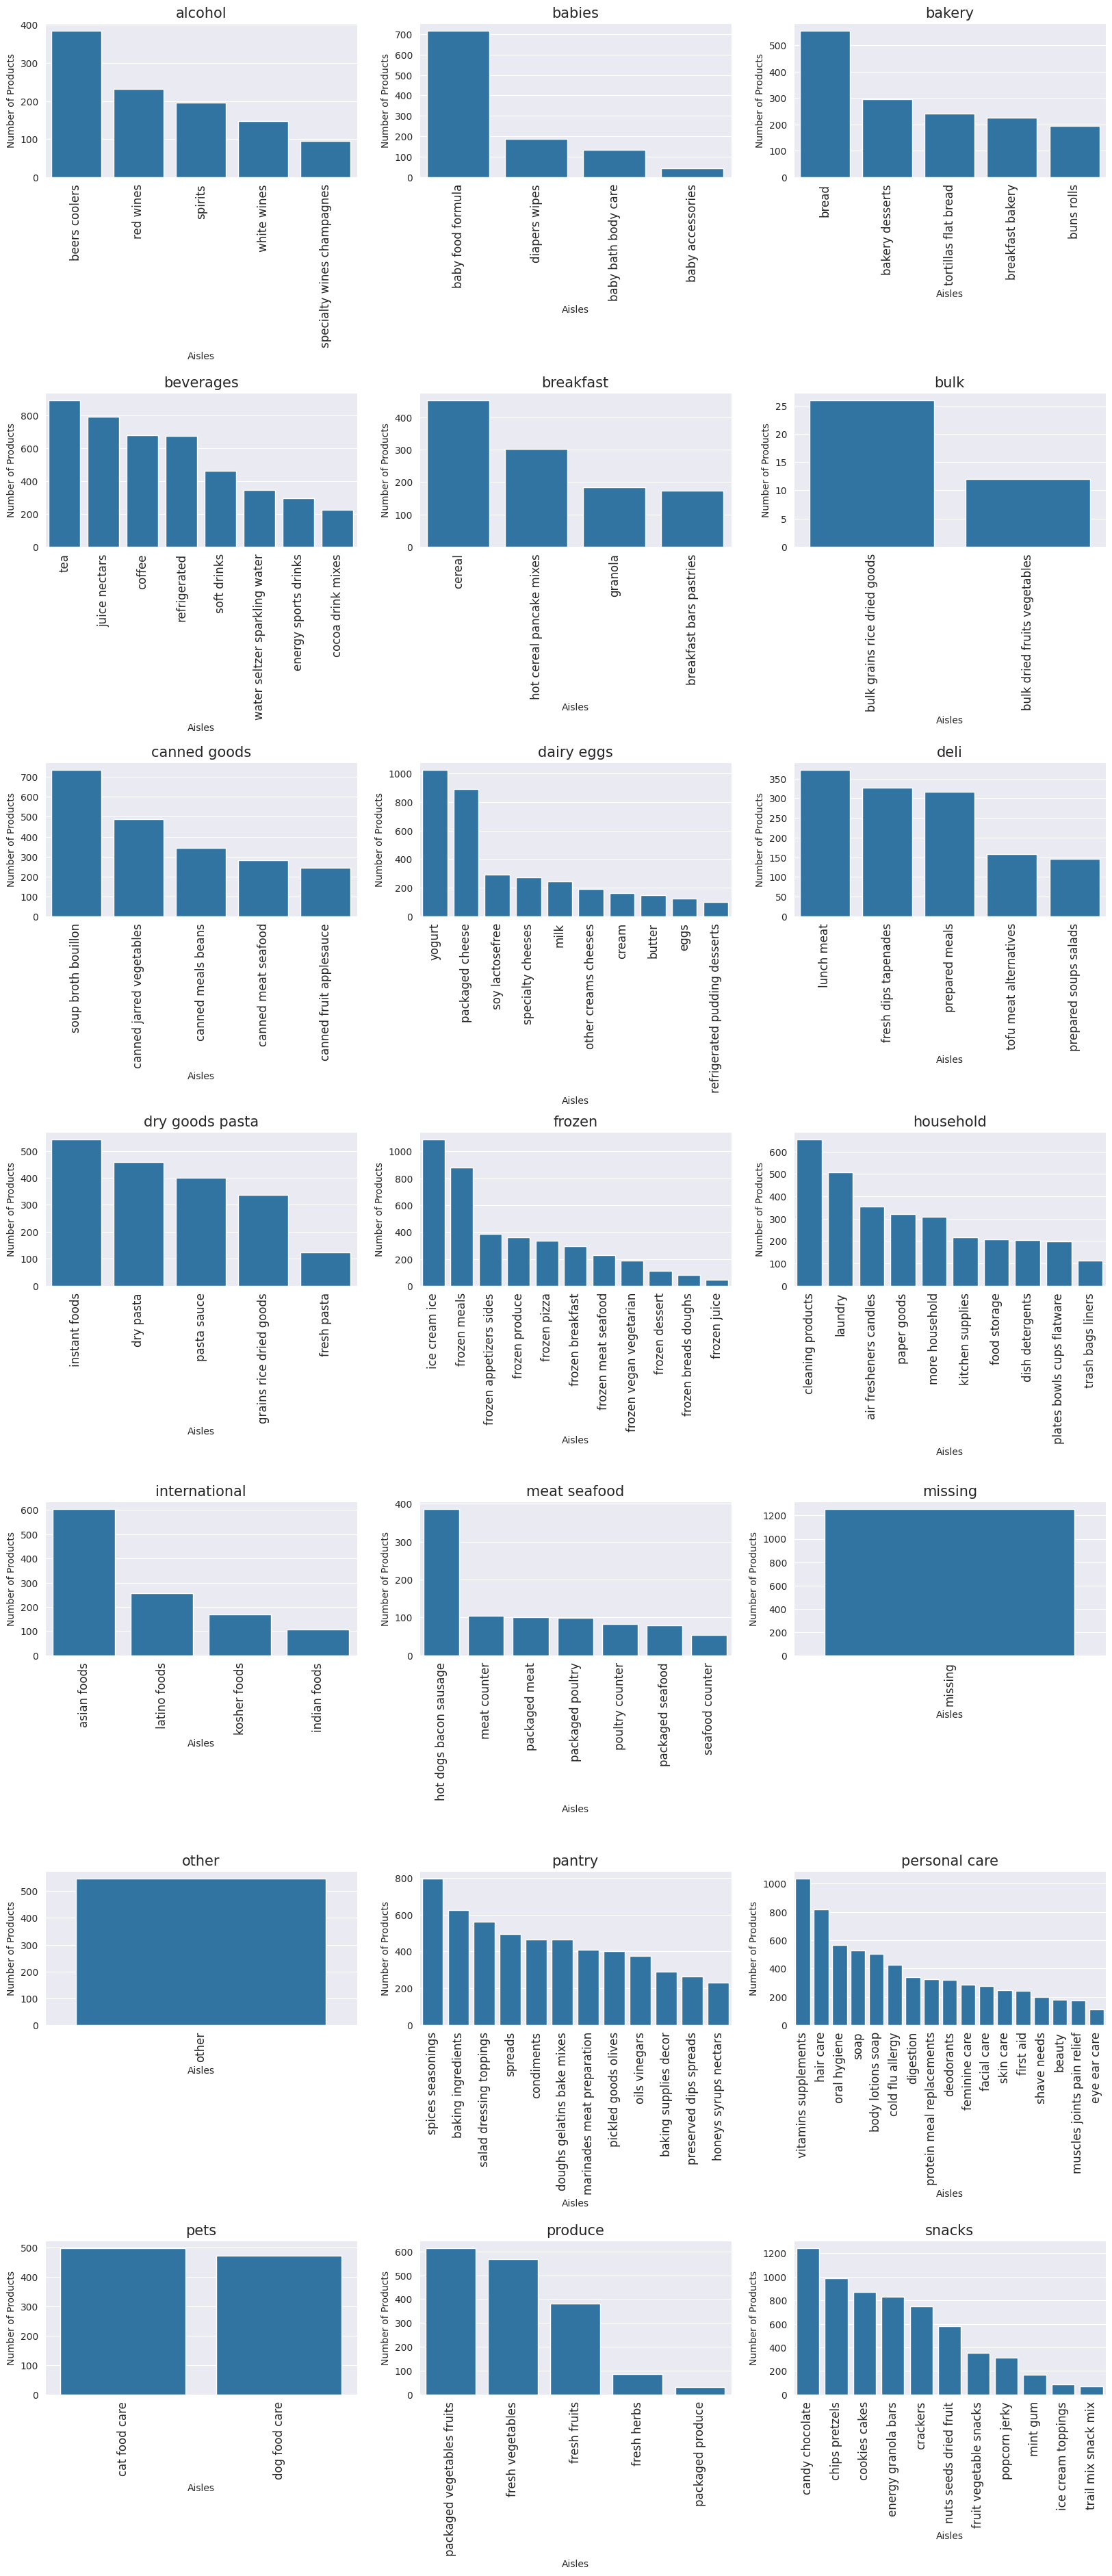

In [ ]:
grouped = items.groupby(["department", "aisle"]).agg(Total_products=('product_id', 'count')).reset_index()
grouped = grouped.sort_values(by='Total_products', ascending=False)

fig, axes = plt.subplots(7, 3, figsize=(20, 45), gridspec_kw=dict(hspace=1.4))

for (dept, group), ax in zip(grouped.groupby("department"), axes.flatten()):
    g = sns.barplot(x=group.aisle, y=group.Total_products, ax=ax)
    ax.set(xlabel="Aisles", ylabel="Number of Products")
    g.set_xticklabels(labels=group.aisle, rotation=90, fontsize=12)
    ax.set_title(dept, fontsize=15)

### Aisles with the Largest Product Variety

We identify the aisles containing the largest number of products. These aisles represent categories with particularly broad product assortments.

In [ ]:
grouped = items.groupby("aisle").agg(Total_products=('product_id', 'count')).reset_index()
grouped['Ratio'] = grouped["Total_products"] / grouped["Total_products"].sum()
grouped = grouped.sort_values(by='Total_products', ascending=False).head(20)
grouped

,aisle,Total_products,Ratio
85,missing,1258,0.025
18,candy chocolate,1246,0.025
71,ice cream ice,1091,0.022
130,vitamins supplements,1038,0.021
133,yogurt,1026,0.021
25,chips pretzels,989,0.020
125,tea,894,0.018
93,packaged cheese,891,0.018
59,frozen meals,880,0.018
31,cookies cakes,874,0.018


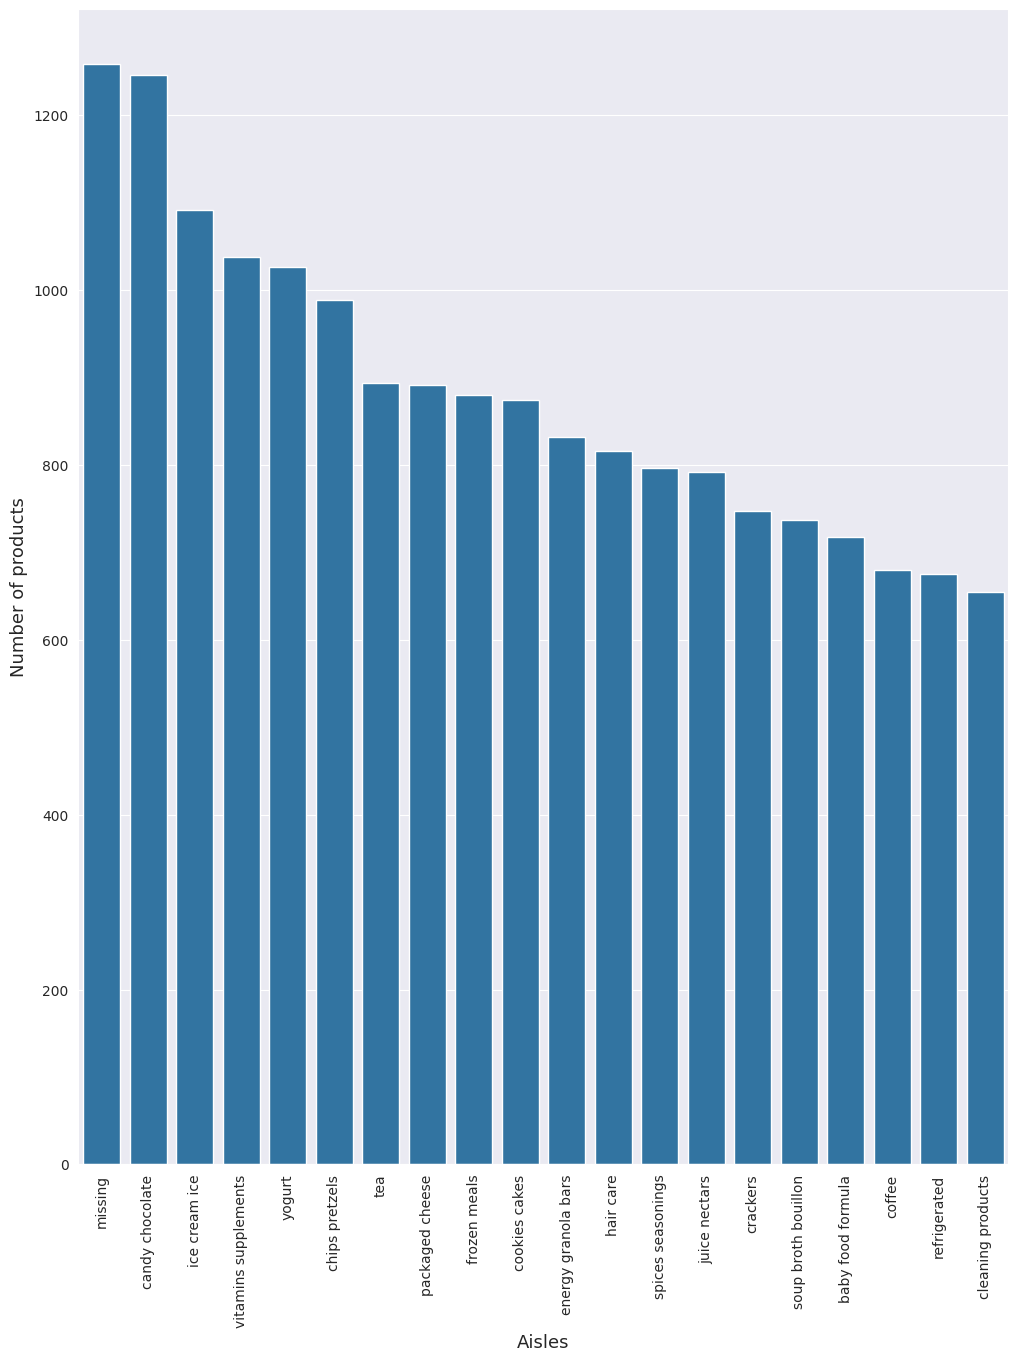

In [ ]:
f, ax = plt.subplots(figsize=(12, 15))
plt.xticks(rotation='vertical')
sns.barplot(x=grouped['aisle'], y=grouped['Total_products'])
plt.ylabel('Number of products', fontsize=13)
plt.xlabel('Aisles', fontsize=13)
plt.show()

## Customer Purchasing Preferences

We now connect customer, order, product, department, and aisle information to examine what types of products customers purchase. This allows us to move from describing the product catalogue to analysing actual purchasing behaviour.

In [ ]:
users_flow = orders[['user_id', 'order_id']].merge(order_products_train[['order_id', 'product_id']],
                                          how='inner', left_on='order_id', right_on='order_id')
users_flow = users_flow.merge(items, how='inner', left_on='product_id',
                                         right_on='product_id')

### Customer Orders by Department

We aggregate customer orders at the department level to identify which product departments account for the largest share of purchasing activity.

In [ ]:
grouped = users_flow.groupby("department").agg(Total_orders=('order_id', 'count')).reset_index()
grouped['Ratio'] = grouped["Total_orders"] / grouped["Total_orders"].sum()
grouped = grouped.sort_values(by='Total_orders', ascending=False)
grouped

,department,Total_orders,Ratio
19,produce,409087,0.295
7,dairy eggs,217051,0.157
20,snacks,118862,0.086
3,beverages,114046,0.082
10,frozen,100426,0.073
16,pantry,81242,0.059
2,bakery,48394,0.035
6,canned goods,46799,0.034
8,deli,44291,0.032
9,dry goods pasta,38713,0.028


The following visualization compares purchasing activity across departments.

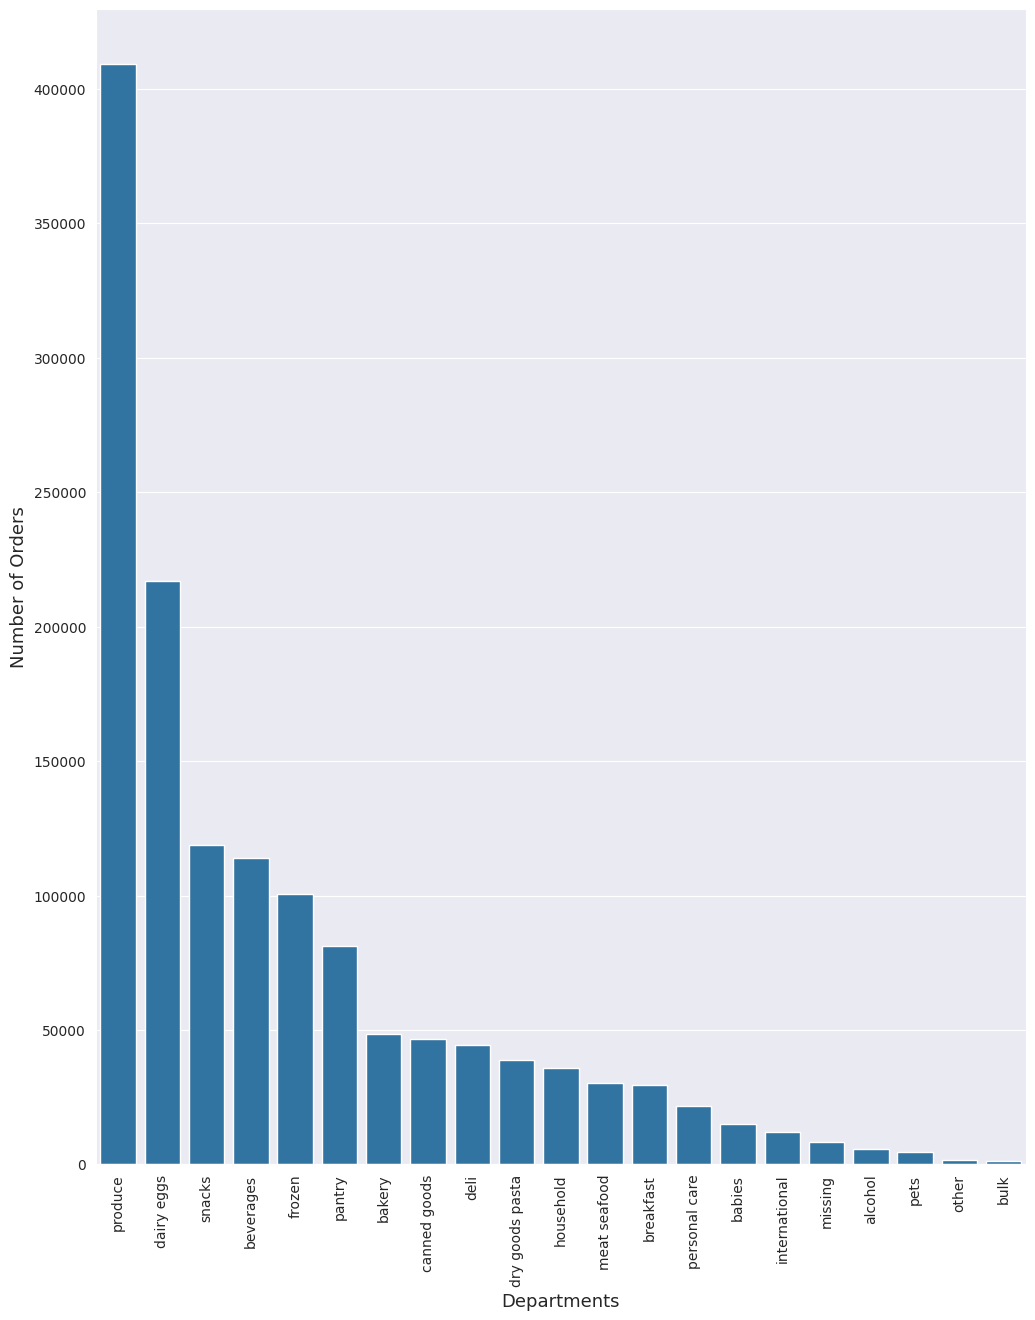

In [ ]:
f, ax = plt.subplots(figsize=(12, 15))
plt.xticks(rotation='vertical')
sns.barplot(x=grouped['department'], y=grouped['Total_orders'])
plt.ylabel('Number of Orders', fontsize=13)
plt.xlabel('Departments', fontsize=13)
plt.show()

### Customer Purchasing Activity Across Aisles

We examine purchasing activity at the aisle level within each department to obtain a more detailed picture of customer preferences.

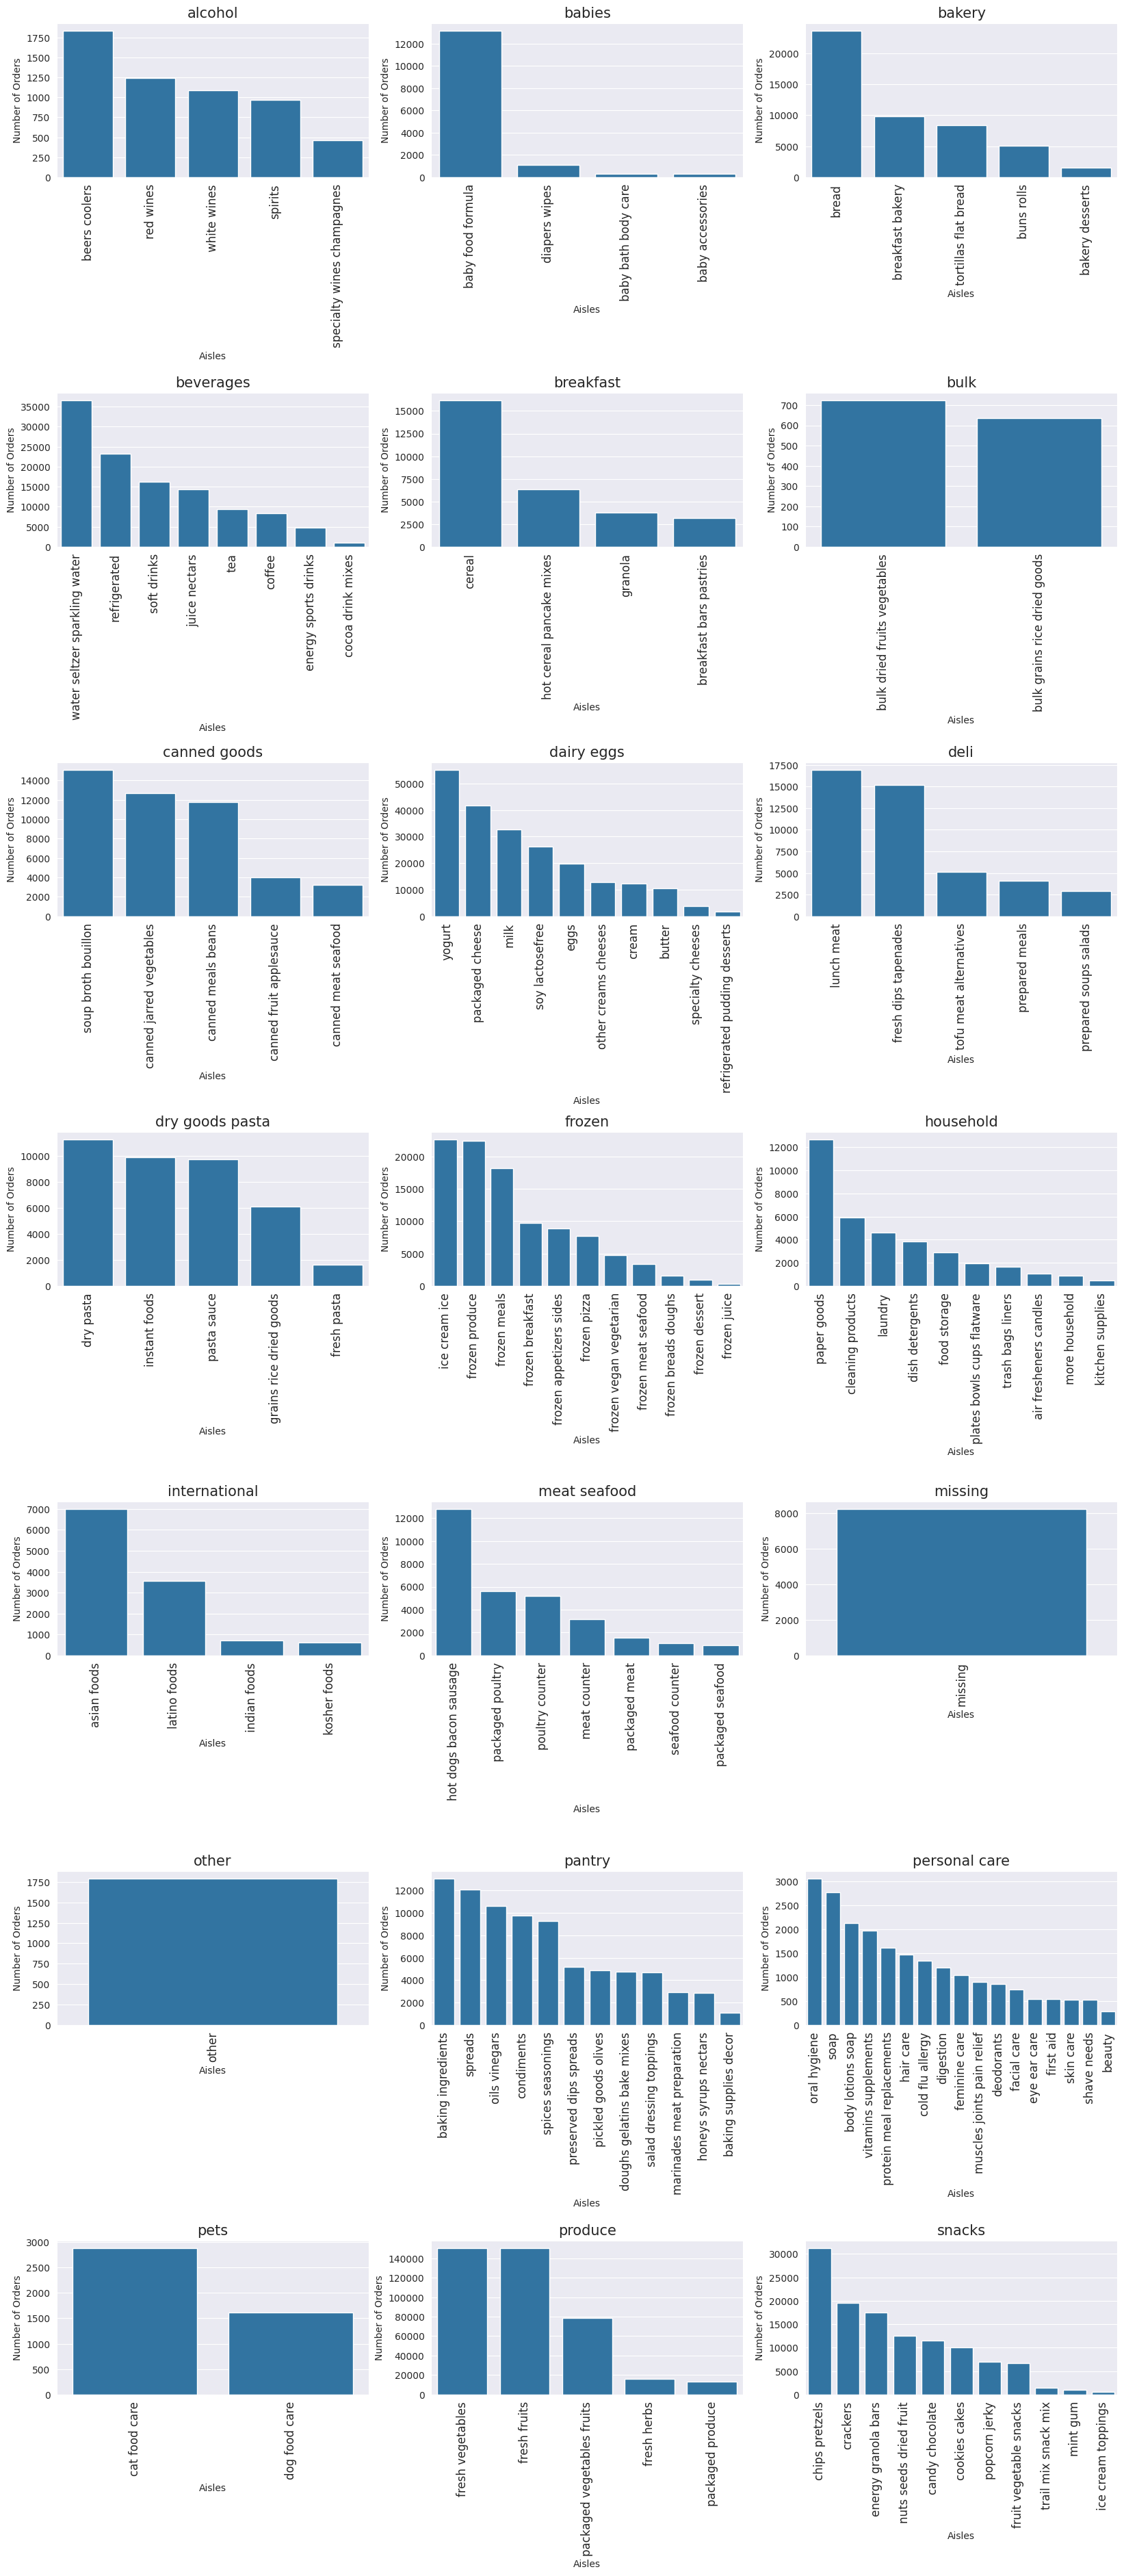

In [ ]:
grouped = users_flow.groupby(["department", "aisle"]).agg(Total_orders=('order_id', 'count')).reset_index()
grouped = grouped.sort_values(by='Total_orders', ascending=False)

fig, axes = plt.subplots(7, 3, figsize=(20, 45), gridspec_kw=dict(hspace=1.4))

for (dept, group), ax in zip(grouped.groupby("department"), axes.flatten()):
    g = sns.barplot(x=group.aisle, y=group.Total_orders, ax=ax)
    ax.set(xlabel="Aisles", ylabel="Number of Orders")
    g.set_xticklabels(labels=group.aisle, rotation=90, fontsize=12)
    ax.set_title(dept, fontsize=15)

### Most Frequently Purchased Aisles

Finally, we identify the aisles receiving the highest number of orders. These categories represent the areas of the product catalogue with the greatest observed purchasing activity.

In [ ]:
grouped = users_flow.groupby("aisle").agg(Total_orders=('order_id', 'count')).reset_index()
grouped['Ratio'] = grouped["Total_orders"] / grouped["Total_orders"].sum()
grouped = grouped.sort_values(by='Total_orders', ascending=False)
grouped.head(10)

,aisle,Total_orders,Ratio
53,fresh vegetables,150609,0.109
50,fresh fruits,150473,0.109
98,packaged vegetables fruits,78493,0.057
133,yogurt,55240,0.040
93,packaged cheese,41699,0.030
131,water seltzer sparkling water,36617,0.026
83,milk,32644,0.024
25,chips pretzels,31269,0.023
119,soy lactosefree,26240,0.019
11,bread,23635,0.017


The following chart presents the top 20 aisles based on the number of orders.

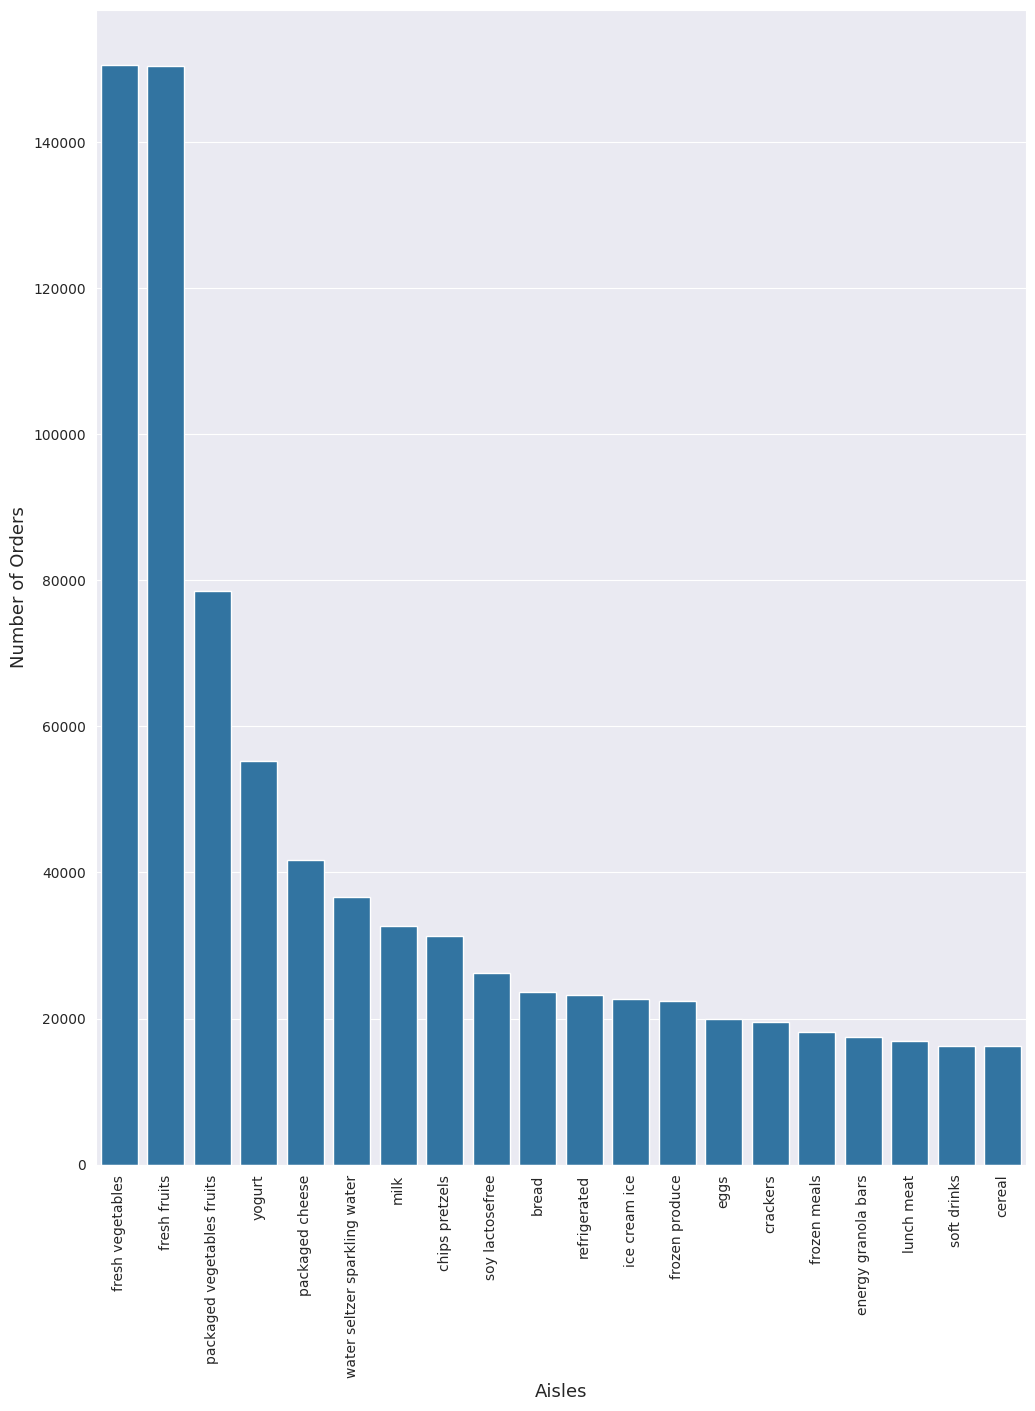

In [ ]:
top_aisles = grouped.sort_values(by='Total_orders', ascending=False).head(20)

f, ax = plt.subplots(figsize=(12, 15))
plt.xticks(rotation='vertical')
sns.barplot(x=top_aisles['aisle'], y=top_aisles['Total_orders'])
plt.ylabel('Number of Orders', fontsize=13)
plt.xlabel('Aisles', fontsize=13)
plt.show()